# Used Cars Dataset Preprocessing

This notebook performs data exploration and preprocessing on a used cars dataset to prepare it for analysis and modeling.

## Import Required Libraries

In [4]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ast
import re
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
import seaborn as sns
sns.set_style("whitegrid")  # This sets the 'seab_
sns.set_palette('colorblind')
%matplotlib inline

## 1. Data Loading and Initial Inspection

Let's load the CSV file and examine its basic structure.

In [6]:
# Define the path to the dataset
file_path = '../data/samples/used_cars_1k.csv'  # Adjust this path as needed

# Load the CSV file into a pandas DataFrame
df = pd.read_csv(file_path)

# Display basic information about the dataset
print(f"Dataset shape: {df.shape}")
print(f"\nMemory usage: {df.memory_usage().sum() / 1024**2:.2f} MB")

Dataset shape: (1000, 66)

Memory usage: 0.49 MB


In [7]:
# Display the first few rows of the dataset
df.head()

,vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,combine_fuel_economy,...,transmission,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year
0,ZACNJABB5KPJ92081,35.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,Bayamon,NaN,NaN,...,A,9-Speed Automatic Overdrive,t83804,Latitude FWD,NaN,FWD,Front-Wheel Drive,101.2 in,79.6 in,2019
1,SALCJ2FX1LH858117,38.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,9-Speed Automatic Overdrive,t86759,S AWD,NaN,AWD,All-Wheel Drive,107.9 in,85.6 in,2020
2,JF1VA2M67G9829723,35.4 in,NaN,NaN,NaN,Sedan,NaN,Guaynabo,17.0,NaN,...,M,6-Speed Manual,t58994,Base,NaN,AWD,All-Wheel Drive,104.3 in,78.9 in,2016
3,SALRR2RV0L2433391,37.6 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,8-Speed Automatic Overdrive,t86074,V6 HSE AWD,NaN,AWD,All-Wheel Drive,115 in,87.4 in,2020
4,SALCJ2FXXLH862327,38.1 in,NaN,NaN,NaN,SUV / Crossover,NaN,San Juan,NaN,NaN,...,A,9-Speed Automatic Overdrive,t86759,S AWD,NaN,AWD,All-Wheel Drive,107.9 in,85.6 in,2020


In [8]:
# Display information about columns and data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 66 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   vin                      1000 non-null   object 
 1   back_legroom             977 non-null    object 
 2   bed                      0 non-null      float64
 3   bed_height               64 non-null     object 
 4   bed_length               64 non-null     object 
 5   body_type                996 non-null    object 
 6   cabin                    1 non-null      object 
 7   city                     1000 non-null   object 
 8   city_fuel_economy        739 non-null    float64
 9   combine_fuel_economy     0 non-null      float64
 10  daysonmarket             1000 non-null   int64  
 11  dealer_zip               1000 non-null   int64  
 12  description              968 non-null    object 
 13  engine_cylinders         985 non-null    object 
 14  engine_displacement      

In [19]:
# Display statistical summary of the dataset
df.describe(include='all')

,vin,back_legroom,bed,bed_height,bed_length,body_type,cabin,city,city_fuel_economy,combine_fuel_economy,...,transmission,transmission_display,trimId,trim_name,vehicle_damage_category,wheel_system,wheel_system_display,wheelbase,width,year
count,1000,977,0.0,64,64,996,1,1000,739.000000,0.0,...,998,998,981,981,0.0,977,977,977,977,1000.000000
unique,1000,107,NaN,1,15,9,1,10,NaN,NaN,...,4,19,675,376,NaN,5,5,148,151,NaN
top,WBAKF9C53CE672450,38.6 in,NaN,--,78.9 in,SUV / Crossover,Crew Cab,Bay Shore,NaN,NaN,...,A,Automatic,t87086,Limited 4WD,NaN,AWD,All-Wheel Drive,106.3 in,70.9 in,NaN
freq,1,56,NaN,64,25,568,1,228,NaN,NaN,...,908,257,12,38,NaN,342,342,66,57,NaN
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.699594,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2016.197000
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5.780224,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.194495
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1989.000000
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.000000
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,23.500000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2020.000000


In [10]:
# Check the number of unique values for each column
unique_counts = df.nunique().sort_values(ascending=False)
print(f"Number of unique values per column:\n{unique_counts}")

Number of unique values per column:
vin                        1000
listing_id                 1000
description                 914
main_picture_url            846
mileage                     757
                           ... 
is_oemcpo                     1
is_certified                  0
bed                           0
combine_fuel_economy          0
vehicle_damage_category       0
Length: 66, dtype: int64


## 2. Missing Values Analysis

Let's identify columns with missing values and the percentage of missing data in each column.

In [12]:
# Calculate the percentage of missing values for each column
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Create a DataFrame to display missing values information
missing_info = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': missing_percentage
}).sort_values('Percentage (%)', ascending=False)

# Filter to display only columns with missing values
missing_columns = missing_info[missing_info['Missing Values'] > 0]
missing_columns

,Missing Values,Percentage (%)
combine_fuel_economy,1000,100.0
bed,1000,100.0
is_certified,1000,100.0
vehicle_damage_category,1000,100.0
cabin,999,99.9
bed_length,936,93.6
bed_height,936,93.6
is_cpo,821,82.1
is_oemcpo,821,82.1
owner_count,293,29.3


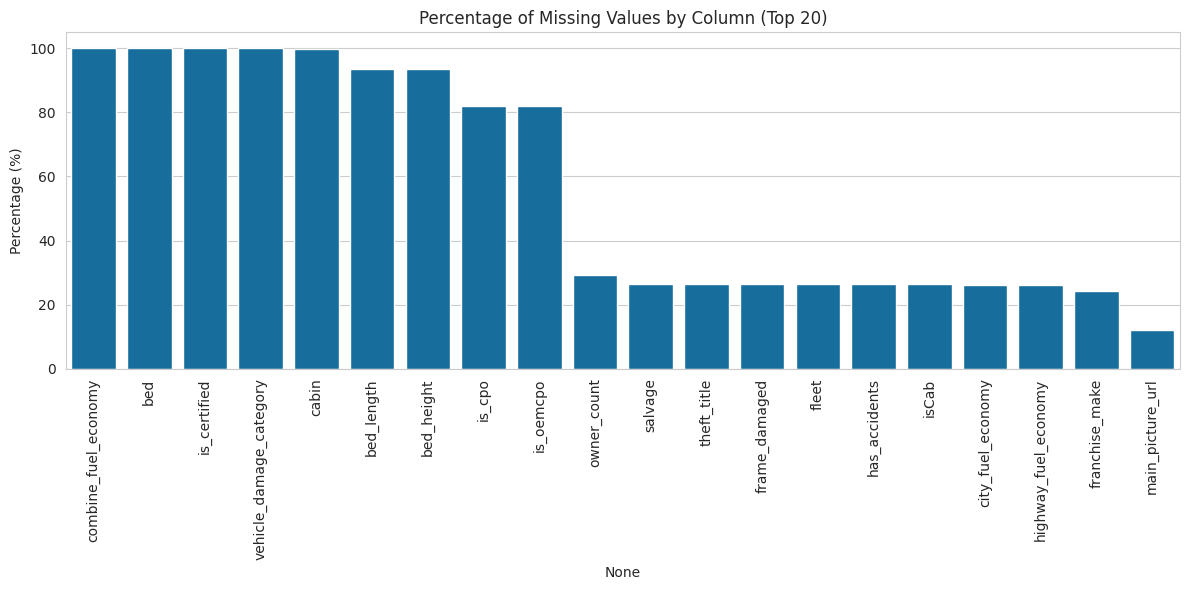

In [13]:
# Visualize columns with missing values (top 20)
plt.figure(figsize=(12, 6))
missing_cols = missing_columns.head(20)
sns.barplot(x=missing_cols.index, y='Percentage (%)', data=missing_cols)
plt.xticks(rotation=90)
plt.title('Percentage of Missing Values by Column (Top 20)')
plt.tight_layout()
plt.show()

In [14]:
# Check for empty strings or common placeholders in string columns
string_cols = df.select_dtypes(include=['object']).columns

# Dictionary to store columns with empty strings and their counts
empty_strings = {}
none_values = {}

for col in string_cols:
    # Count empty strings
    empty_count = (df[col] == '').sum()
    if empty_count > 0:
        empty_strings[col] = empty_count
    
    # Count 'None' or 'none' values
    none_count = ((df[col] == 'None') | (df[col] == 'none')).sum()
    if none_count > 0:
        none_values[col] = none_count

print("Columns with empty strings:")
for col, count in empty_strings.items():
    print(f"- {col}: {count} ({count/len(df)*100:.2f}%)")

print("\nColumns with 'None' values:")
for col, count in none_values.items():
    print(f"- {col}: {count} ({count/len(df)*100:.2f}%)")

Columns with empty strings:

Columns with 'None' values:


## 3. Data Cleaning Functions

Let's define functions to clean and transform the data.

In [20]:
# Function to clean numeric columns with units
def clean_numeric_with_units(series, unit_str):
    """Clean numeric columns with units (e.g., '10.5 in', '15 gal')."""
    if series.dtype == 'object':
        # First replace any '--' or other non-numeric placeholders with NaN
        cleaned = series.replace('--', np.nan)
        # Then remove the unit string and convert to float, handling errors
        try:
            return pd.to_numeric(
                cleaned.str.replace(unit_str, '').str.strip(), 
                errors='coerce'
            )
        except Exception as e:
            print(f"Error converting {series.name}: {e}")
            # Fallback method for troubleshooting
            problematic = cleaned.str.replace(unit_str, '').str.strip()
            print(f"Sample problematic values: {problematic[problematic.notna()].sample(min(5, len(problematic))).tolist()}")
            return pd.to_numeric(problematic, errors='coerce')
    return series

# Function to convert string boolean columns to actual boolean values
def convert_to_boolean(series):
    """Convert string 'True'/'False' to actual boolean values."""
    if series.dtype == 'object':
        # Replace empty strings with NaN first
        series = series.replace('', np.nan)
        # Convert to boolean (treating NaN as False)
        return series.map({'True': True, 'False': False}).fillna(False)
    return series

# Function to safely parse string lists
def parse_string_list(value):
    """Parse a string representation of a list into an actual list."""
    if pd.isna(value) or value == '':
        return []
    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []

# Function to extract numeric values from power and torque strings
def extract_power_value(power_str):
    """Extract horsepower value from power string (e.g., '177 hp @ 5,750 RPM')."""
    if pd.isna(power_str) or power_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(power_str))
    if match:
        return float(match.group(1))
    return np.nan

def extract_rpm(rpm_str):
    """Extract RPM value from a string (e.g., '177 hp @ 5,750 RPM')."""
    if pd.isna(rpm_str) or rpm_str == '':
        return np.nan
    match = re.search(r'@\s*(\d[\d,]*)\s*RPM', str(rpm_str))
    if match:
        rpm_str = match.group(1).replace(',', '')
        return float(rpm_str)
    return np.nan

def extract_torque_value(torque_str):
    """Extract torque value from torque string (e.g., '200 lb-ft @ 1,750 RPM')."""
    if pd.isna(torque_str) or torque_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(torque_str))
    if match:
        return float(match.group(1))
    return np.nan

# Function to extract seats from maximum_seating
def extract_seats(seating_str):
    """Extract number of seats from maximum_seating (e.g., '5 seats')."""
    if pd.isna(seating_str) or seating_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(seating_str))
    if match:
        return int(match.group(1))
    return np.nan

# Function to extract engine cylinders as a number
def extract_cylinders(cylinder_str):
    """Extract number of cylinders from engine_cylinders (e.g., 'I4', 'V6')."""
    if pd.isna(cylinder_str) or cylinder_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(cylinder_str))
    if match:
        return int(match.group(1))
    return np.nan

# Function to clean description field
def clean_description(desc):
    """Clean description field by removing special tags."""
    if pd.isna(desc) or desc == '':
        return ''
    # Remove special tags like [!@@Additional Info@@!]
    return re.sub(r'\[!@@.*?@@!\]', '', str(desc)).strip()

## 4. Data Processing and Cleaning

Now let's apply our cleaning functions to process the dataset.

In [21]:
# Create a copy of the original DataFrame to preserve the original data
df_clean = df.copy()

### 4.1 Remove Columns with High Missing Values

In [22]:
# Identify and remove columns with a high percentage of missing values (> 70%)
high_missing_cols = missing_percentage[missing_percentage > 70].index.tolist()
print(f"Removing {len(high_missing_cols)} columns with >70% missing values:")
print(high_missing_cols)

df_clean = df_clean.drop(columns=high_missing_cols)

Removing 9 columns with >70% missing values:
['bed', 'bed_height', 'bed_length', 'cabin', 'combine_fuel_economy', 'is_certified', 'is_cpo', 'is_oemcpo', 'vehicle_damage_category']


### 4.2 Clean Numeric Columns with Units

In [23]:
# Clean numeric columns with units
columns_with_inches = ['back_legroom', 'front_legroom', 'height', 'length', 'wheelbase', 'width']
for col in columns_with_inches:
    if col in df_clean.columns:
        print(f"Cleaning column: {col}")
        df_clean[col] = clean_numeric_with_units(df_clean[col], ' in')

# Clean fuel_tank_volume (contains 'gal')
if 'fuel_tank_volume' in df_clean.columns:
    print(f"Cleaning column: fuel_tank_volume")
    df_clean['fuel_tank_volume'] = clean_numeric_with_units(df_clean['fuel_tank_volume'], ' gal')

# Check the result of conversion
print("\nSample values after cleaning:")
for col in columns_with_inches + ['fuel_tank_volume']:
    if col in df_clean.columns:
        print(f"{col}: {df_clean[col].sample(3).tolist()}")

Cleaning column: back_legroom
Cleaning column: front_legroom
Cleaning column: height
Cleaning column: length
Cleaning column: wheelbase
Cleaning column: width
Cleaning column: fuel_tank_volume

Sample values after cleaning:
back_legroom: [nan, 39.7, 39.0]
front_legroom: [45.3, 42.5, 41.3]
height: [57.2, 73.9, 66.9]
length: [183.5, 167.6, nan]
wheelbase: [108.3, 107.3, 115.1]
width: [73.6, 73.0, 73.2]
fuel_tank_volume: [14.5, 24.6, 18.5]


### 4.3 Convert String Booleans to Actual Booleans

In [24]:
# Convert string boolean columns to actual boolean values
boolean_columns = [
    'fleet', 'frame_damaged', 'franchise_dealer', 'has_accidents', 'isCab',
    'is_certified', 'is_cpo', 'is_new', 'is_oemcpo', 'salvage', 'theft_title'
]

for col in boolean_columns:
    if col in df_clean.columns:
        df_clean[col] = convert_to_boolean(df_clean[col])

### 4.4 Parse String Lists

In [25]:
# Parse major_options from string representation to actual list
if 'major_options' in df_clean.columns:
    # Create a new column with parsed lists
    df_clean['major_options_list'] = df_clean['major_options'].apply(parse_string_list)
    
    # Create a feature for the number of options
    df_clean['num_major_options'] = df_clean['major_options_list'].apply(len)

### 4.5 Extract Values from Complex String Columns

In [26]:
# Extract horsepower and RPM from the power column
if 'power' in df_clean.columns:
    df_clean['horsepower_extracted'] = df_clean['power'].apply(extract_power_value)
    df_clean['horsepower_rpm'] = df_clean['power'].apply(extract_rpm)
    # Compare extracted horsepower with existing horsepower column if it exists
    if 'horsepower' in df_clean.columns:
        matching = np.isclose(df_clean['horsepower_extracted'], df_clean['horsepower'], equal_nan=True).mean() * 100
        print(f"Percentage of matching horsepower values: {matching:.2f}%")

# Fix error in extract_torque_value function (uses power_str instead of torque_str)
def extract_torque_value_fixed(torque_str):
    """Extract torque value from torque string (e.g., '200 lb-ft @ 1,750 RPM')."""
    if pd.isna(torque_str) or torque_str == '':
        return np.nan
    match = re.search(r'(\d+)', str(torque_str))
    if match:
        return float(match.group(1))
    return np.nan

# Extract torque value and RPM from the torque column
if 'torque' in df_clean.columns:
    df_clean['torque_value'] = df_clean['torque'].apply(extract_torque_value_fixed)
    df_clean['torque_rpm'] = df_clean['torque'].apply(extract_rpm)

# Extract number of seats from maximum_seating
if 'maximum_seating' in df_clean.columns:
    df_clean['seats'] = df_clean['maximum_seating'].apply(extract_seats)
    
# Extract number of cylinders from engine_cylinders
if 'engine_cylinders' in df_clean.columns:
    df_clean['cylinders'] = df_clean['engine_cylinders'].apply(extract_cylinders)
    # Show the mapping from engine_cylinders to extracted cylinders
    sample_cylinders = df_clean[['engine_cylinders', 'cylinders']].dropna().sample(min(10, len(df_clean)))
    print("\nSample cylinder extractions:")
    print(sample_cylinders)

Percentage of matching horsepower values: 87.60%

Sample cylinder extractions:
         engine_cylinders  cylinders
273                    I4        4.0
39                     I4        4.0
27                     I4        4.0
839                    I4        4.0
838                    I4        4.0
844  V6 Flex Fuel Vehicle        6.0
999                    I6        6.0
564                    I4        4.0
570                    V6        6.0
377                    I4        4.0


### 4.6 Convert Date/Time Columns

In [27]:
# Convert listed_date to datetime
if 'listed_date' in df_clean.columns:
    df_clean['listed_date'] = pd.to_datetime(df_clean['listed_date'], errors='coerce')
    
    # Extract useful features from the date
    df_clean['listed_year'] = df_clean['listed_date'].dt.year
    df_clean['listed_month'] = df_clean['listed_date'].dt.month
    df_clean['listed_day'] = df_clean['listed_date'].dt.day
    df_clean['listed_dayofweek'] = df_clean['listed_date'].dt.dayofweek
    
    # Calculate days on market (comparing with the provided daysonmarket column)
    current_date = datetime.now()
    df_clean['days_on_market_calculated'] = (current_date - df_clean['listed_date']).dt.days

### 4.7 Clean Text Fields

In [28]:
# Clean description field
if 'description' in df_clean.columns:
    df_clean['description_cleaned'] = df_clean['description'].apply(clean_description)
    
    # Create a feature for description length
    df_clean['description_length'] = df_clean['description_cleaned'].apply(lambda x: len(str(x)) if not pd.isna(x) else 0)

## 5. Feature Engineering

In [30]:
# Calculate car age if 'year' column exists
if 'year' in df_clean.columns:
    current_year = datetime.now().year
    df_clean['car_age'] = current_year - df_clean['year']

# Create feature to indicate if the car is from a luxury brand
luxury_brands = ['BMW', 'Mercedes-Benz', 'Audi', 'Lexus', 'Porsche', 'Land Rover', 
                 'Jaguar', 'Acura', 'Infiniti', 'Volvo', 'Cadillac', 'Lincoln', 'Tesla']

if 'make_name' in df_clean.columns:
    df_clean['is_luxury_make'] = df_clean['make_name'].isin(luxury_brands)

# Create feature to indicate if a car has bed features (likely a pickup truck)
# First check if the bed columns still exist in df_clean (they might have been dropped earlier)
bed_columns = ['bed', 'bed_height', 'bed_length']
bed_columns_exist = all(col in df_clean.columns for col in bed_columns)

if bed_columns_exist and 'body_type' in df_clean.columns:
    # All bed columns exist in df_clean, proceed as planned
    df_clean['has_bed_feature'] = (
        df_clean[bed_columns].notna().any(axis=1) | 
        (df_clean['body_type'] == 'Pickup Truck')
    )
elif 'body_type' in df_clean.columns:
    # Fallback: if bed columns were dropped, just use body_type
    df_clean['has_bed_feature'] = df_clean['body_type'] == 'Pickup Truck'
    print("Note: bed columns were not found in the DataFrame, using only body_type for has_bed_feature")

Note: bed columns were not found in the DataFrame, using only body_type for has_bed_feature


## 6. Handle Remaining Missing Values

In [31]:
# Check remaining missing values
remaining_missing = (df_clean.isnull().sum() / len(df_clean)) * 100
remaining_missing = remaining_missing[remaining_missing > 0].sort_values(ascending=False)

print("Remaining columns with missing values:")
print(remaining_missing)

Remaining columns with missing values:
owner_count             29.3
highway_fuel_economy    26.1
city_fuel_economy       26.1
franchise_make          24.4
main_picture_url        12.1
torque_value             7.9
torque_rpm               7.9
torque                   7.9
horsepower_extracted     6.4
horsepower_rpm           6.4
power                    6.4
back_legroom             5.5
major_options            4.9
mileage                  3.5
description              3.2
interior_color           3.2
front_legroom            3.2
fuel_tank_volume         2.5
engine_displacement      2.4
horsepower               2.4
seats                    2.4
width                    2.4
height                   2.4
wheelbase                2.4
length                   2.4
maximum_seating          2.3
wheel_system_display     2.3
wheel_system             2.3
trim_name                1.9
trimId                   1.9
engine_cylinders         1.5
cylinders                1.5
engine_type              1.5
fuel

In [32]:
# Impute missing numerical values
numerical_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Choose appropriate imputation strategy for each numerical column
for col in numerical_cols:
    # Skip columns that shouldn't be imputed (e.g., target variables like price)
    if col == 'price':
        continue
        
                
    # If missing values in this column
    if df_clean[col].isnull().sum() > 0:
        # Use median for most columns to be robust against outliers
        median_value = df_clean[col].median()
        
        # Create an indicator feature before imputation
        df_clean[f'{col}_missing'] = df_clean[col].isnull().astype(int)
        
        # Impute with median
        df_clean[col] = df_clean[col].fillna(median_value)
        
        print(f"Imputed {col} with median value: {median_value}")

Imputed back_legroom with median value: 37.7
Imputed city_fuel_economy with median value: 20.0
Imputed engine_displacement with median value: 2500.0
Imputed front_legroom with median value: 41.4
Imputed fuel_tank_volume with median value: 18.5
Imputed height with median value: 66.0
Imputed highway_fuel_economy with median value: 27.0
Imputed horsepower with median value: 246.0
Imputed length with median value: 188.3
Imputed mileage with median value: 36261.0
Imputed owner_count with median value: 1.0
Imputed seller_rating with median value: 3.4477611940298507
Imputed wheelbase with median value: 110.55
Imputed width with median value: 78.5
Imputed horsepower_extracted with median value: 246.0
Imputed horsepower_rpm with median value: 6000.0
Imputed torque_value with median value: 260.0
Imputed torque_rpm with median value: 4000.0
Imputed seats with median value: 5.0
Imputed cylinders with median value: 4.0


In [33]:
# Impute missing categorical values
categorical_cols = df_clean.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # If missing values in this column
    if df_clean[col].isnull().sum() > 0 or (df_clean[col] == '').sum() > 0:
        # Replace empty strings with NaN first
        df_clean[col] = df_clean[col].replace('', np.nan)
        
        # Create an indicator feature
        df_clean[f'{col}_missing'] = df_clean[col].isnull().astype(int)
        
        # For color fields, use 'Unknown' as replacement
        if 'color' in col:
            df_clean[col] = df_clean[col].fillna('Unknown')
        else:
            # For other categoricals, use most common value (mode)
            mode_value = df_clean[col].mode()[0]
            df_clean[col] = df_clean[col].fillna(mode_value)
            
        print(f"Imputed {col} with value: {df_clean[col].mode()[0]}")

Imputed body_type with value: SUV / Crossover
Imputed description with value: [!@@Additional Info@@!]4-Wheel Disc Brakes,A/C,ABS,AM/FM Stereo,Adaptive Cruise Control,Adjustable Steering Wheel,Aluminum Wheels,Automatic Headlights,Auxiliary Audio Input,Back-Up Camera,Blind Spot Monitor,Bluetooth Connection,Brake Actuated Limited Slip Differential,Brake Assist,Bucket Seats,Child Safety Locks,Climate Control,Cross-Traffic Alert,Cruise Control,Daytime Running Lights,Daytime Running Lights,Driver Adjustable Lumbar,Driver Air Bag,Driver Illuminated Vanity Mirror,Driver Vanity Mirror,Engine Immobilizer,Floor Mats,Front Head Air Bag,Front Side Air Bag,Front Wheel Drive,Generic Sun/Moonroof,HD Radio,Headlights-Auto-Leveling,Heads-Up Display,Heated Front Seat(s),Integrated Turn Signal Mirrors,Intermittent Wipers,Intermittent Wipers,Keyless Entry,Keyless Entry,Keyless Start,Knee Air Bag,Lane Departure Warning,Lane Departure Warning,Lane Keeping Assist,Lane Keeping Assist,Leather Seats,Leather Stee

## 7. Handle Duplicate Entries

In [34]:
# Check for duplicates based on VIN
if 'vin' in df_clean.columns:
    vin_counts = df_clean['vin'].value_counts()
    duplicated_vins = vin_counts[vin_counts > 1].index
    
    print(f"Number of VINs appearing more than once: {len(duplicated_vins)}")
    print(f"Total duplicate rows based on VIN: {sum(vin_counts[vin_counts > 1]) - len(duplicated_vins)}")
    
    # If duplicates exist, keep the most recent listing for each VIN
    if len(duplicated_vins) > 0 and 'listed_date' in df_clean.columns:
        # Sort by listed_date (descending) and keep first occurrence of each VIN
        df_clean = df_clean.sort_values('listed_date', ascending=False)
        df_clean = df_clean.drop_duplicates(subset=['vin'], keep='first')
        print(f"After removing duplicates, dataset shape: {df_clean.shape}")

Number of VINs appearing more than once: 0
Total duplicate rows based on VIN: 0


## 8. Handle Outliers in Numerical Features

In [35]:
# Function to detect and visualize outliers
def detect_outliers(df, column):
    """Detect and visualize outliers in a numerical column using boxplot and distribution."""
    if column not in df.columns or df[column].dtype not in ['int64', 'float64']:
        return
    
    # Calculate IQR
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    
    # Define outlier bounds
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    outlier_percentage = len(outliers) / len(df) * 100
    
    print(f"Column: {column}")
    print(f"Number of outliers: {len(outliers)} ({outlier_percentage:.2f}%)")
    print(f"Outlier bounds: [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Min: {df[column].min()}, Max: {df[column].max()}")
    
    # Visualize outliers
    plt.figure(figsize=(14, 6))
    
    # Box plot to show outliers
    plt.subplot(1, 2, 1)
    sns.boxplot(x=df[column])
    plt.title(f'Box Plot of {column}')
    
    # Distribution plot
    plt.subplot(1, 2, 2)
    sns.histplot(df[column], kde=True)
    plt.title(f'Distribution of {column}')
    plt.axvline(lower_bound, color='red', linestyle='--', label=f'Lower bound: {lower_bound:.2f}')
    plt.axvline(upper_bound, color='red', linestyle='--', label=f'Upper bound: {upper_bound:.2f}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return lower_bound, upper_bound

Column: price
Number of outliers: 74 (7.40%)
Outlier bounds: [-11680.88, 55020.12]
Min: 1850.0, Max: 135465.0


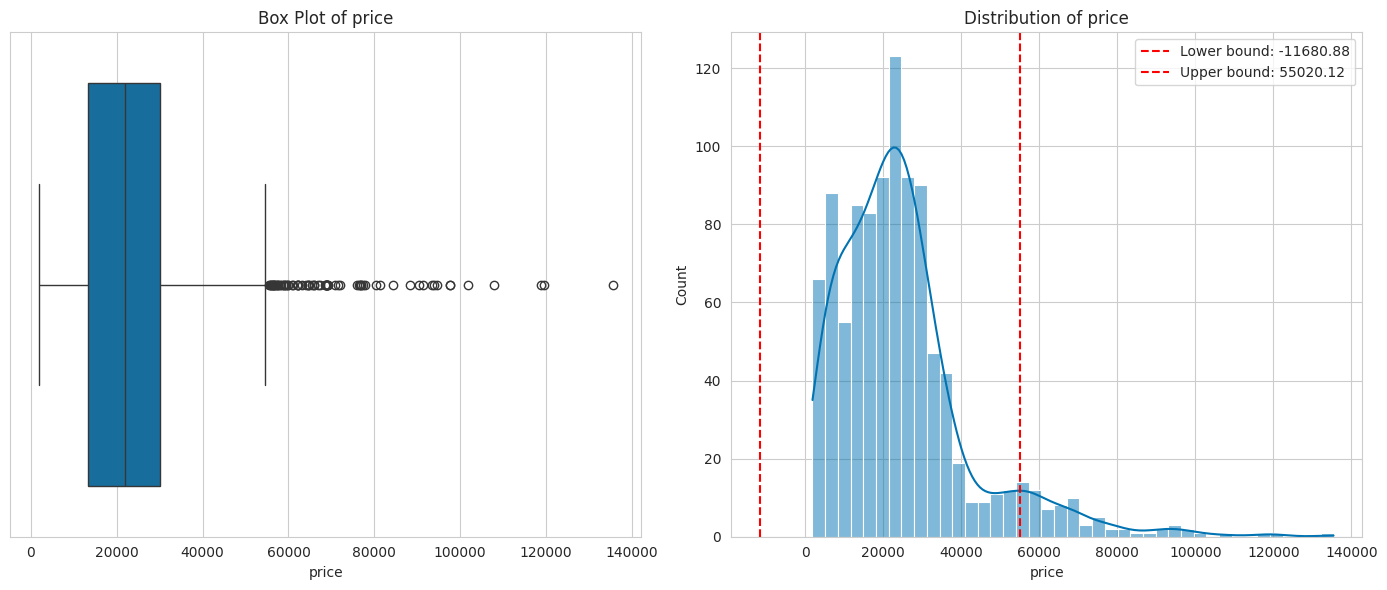

Column: mileage
Number of outliers: 9 (0.90%)
Outlier bounds: [-109502.88, 189896.12]
Min: 0.0, Max: 220355.0


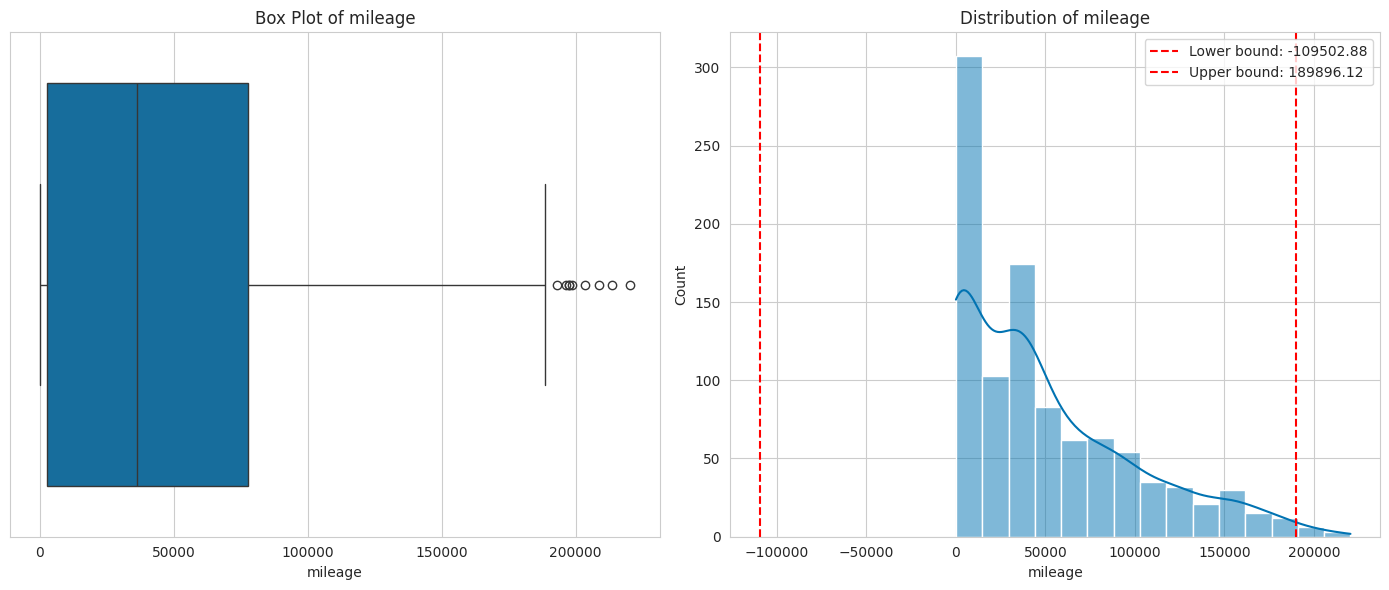

Column: horsepower_extracted
Number of outliers: 14 (1.40%)
Outlier bounds: [2.50, 478.50]
Min: 78.0, Max: 797.0


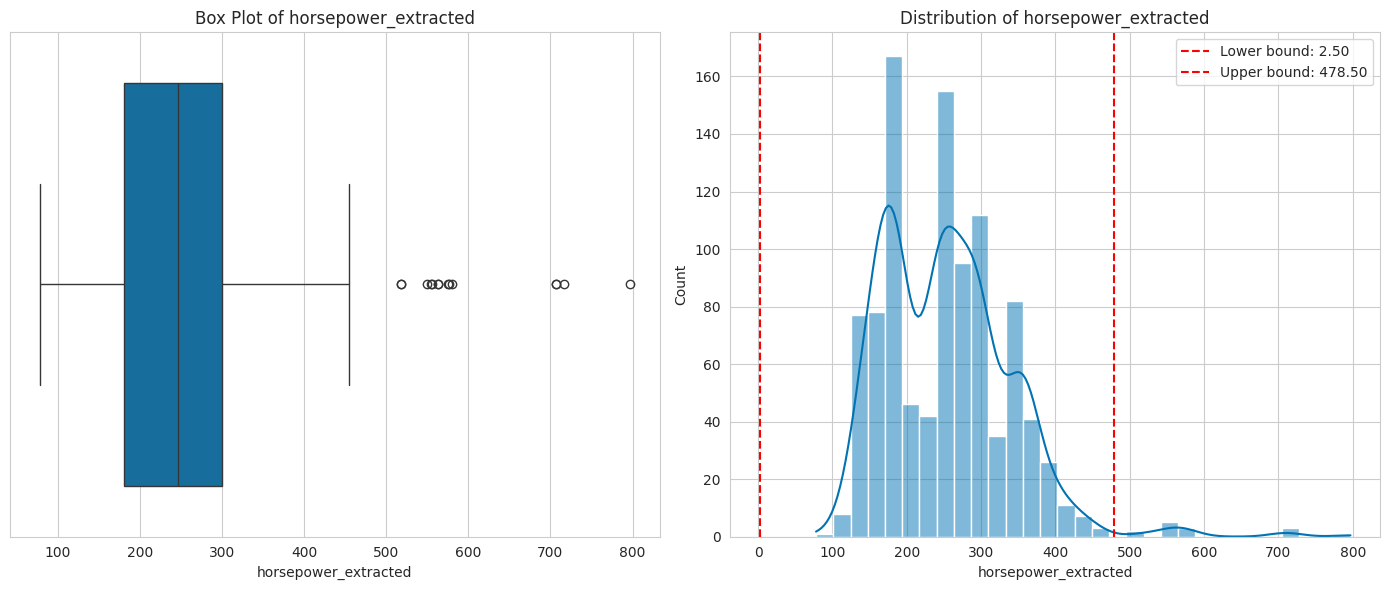

Column: car_age
Number of outliers: 13 (1.30%)
Outlier bounds: [-4.00, 20.00]
Min: 4, Max: 36


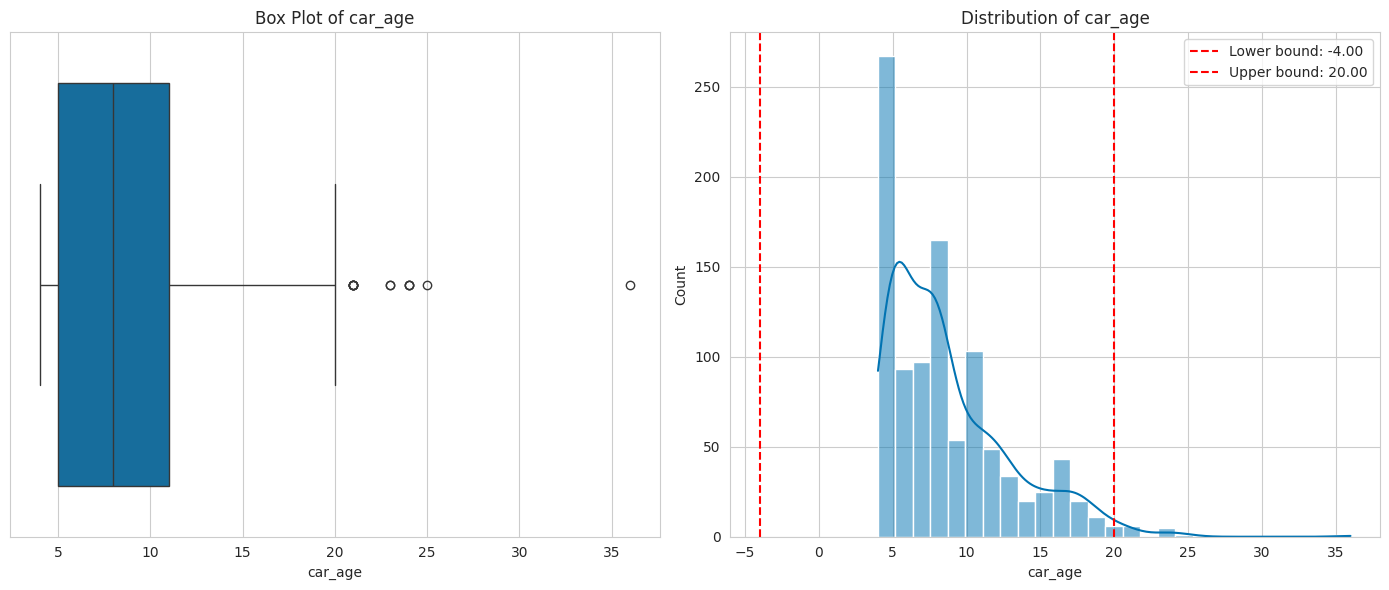

In [36]:
# Analyze potential outliers in key numerical columns
key_numerical_cols = ['price', 'mileage', 'horsepower_extracted', 'car_age']

for col in key_numerical_cols:
    if col in df_clean.columns:
        lower_bound, upper_bound = detect_outliers(df_clean, col)

In [37]:
# Handle outliers using capping/winsorization for price
if 'price' in df_clean.columns:
    # Calculate percentile values for capping
    lower_percentile = df_clean['price'].quantile(0.01)  # 1st percentile
    upper_percentile = df_clean['price'].quantile(0.99)  # 99th percentile
    
    # Create a copy of the original price column
    df_clean['price_original'] = df_clean['price']
    
    # Apply capping
    df_clean['price_capped'] = df_clean['price'].clip(lower=lower_percentile, upper=upper_percentile)
    
    # Print info about capping
    print(f"Price capped between ${lower_percentile:.2f} and ${upper_percentile:.2f}")
    print(f"Number of prices capped at lower bound: {(df_clean['price'] < lower_percentile).sum()}")
    print(f"Number of prices capped at upper bound: {(df_clean['price'] > upper_percentile).sum()}")

Price capped between $3499.00 and $91376.60
Number of prices capped at lower bound: 9
Number of prices capped at upper bound: 10


In [38]:
# Handle outliers for mileage
if 'mileage' in df_clean.columns:
    # Calculate percentile values for capping
    lower_percentile = df_clean['mileage'].quantile(0.01)  # 1st percentile
    upper_percentile = df_clean['mileage'].quantile(0.99)  # 99th percentile
    
    # Create a copy of the original mileage column
    df_clean['mileage_original'] = df_clean['mileage']
    
    # Apply capping
    df_clean['mileage_capped'] = df_clean['mileage'].clip(lower=lower_percentile, upper=upper_percentile)
    
    # Print info about capping
    print(f"Mileage capped between {lower_percentile:.2f} and {upper_percentile:.2f} miles")
    print(f"Number of mileages capped at lower bound: {(df_clean['mileage'] < lower_percentile).sum()}")
    print(f"Number of mileages capped at upper bound: {(df_clean['mileage'] > upper_percentile).sum()}")

Mileage capped between 0.00 and 184223.49 miles
Number of mileages capped at lower bound: 0
Number of mileages capped at upper bound: 10


## 9. Data Consistency Checks

In [39]:
# Check consistency between franchise_dealer and franchise_make
if 'franchise_dealer' in df_clean.columns and 'franchise_make' in df_clean.columns:
    # Check if there are any records where franchise_dealer is True but franchise_make is empty
    inconsistent_franchise = df_clean[(df_clean['franchise_dealer'] == True) & 
                                      (df_clean['franchise_make'].isnull() | (df_clean['franchise_make'] == ''))]
    
    print(f"Found {len(inconsistent_franchise)} records where franchise_dealer is True but franchise_make is empty")
    
    # Fix inconsistencies by filling franchise_make with make_name where appropriate
    if len(inconsistent_franchise) > 0 and 'make_name' in df_clean.columns:
        # Where franchise_dealer is True but franchise_make is empty, use make_name
        mask = (df_clean['franchise_dealer'] == True) & (df_clean['franchise_make'].isnull() | (df_clean['franchise_make'] == ''))
        df_clean.loc[mask, 'franchise_make'] = df_clean.loc[mask, 'make_name']
        print(f"Fixed {mask.sum()} inconsistencies by copying values from make_name")

Found 0 records where franchise_dealer is True but franchise_make is empty


In [40]:
# Check consistency between exterior_color and listing_color
if 'exterior_color' in df_clean.columns and 'listing_color' in df_clean.columns:
    # Count records where one is filled but the other is empty
    ext_empty_list_filled = ((df_clean['exterior_color'].isnull() | (df_clean['exterior_color'] == '')) & 
                             df_clean['listing_color'].notna() & (df_clean['listing_color'] != ''))
    
    list_empty_ext_filled = ((df_clean['listing_color'].isnull() | (df_clean['listing_color'] == '')) & 
                             df_clean['exterior_color'].notna() & (df_clean['exterior_color'] != ''))
    
    print(f"Records with empty exterior_color but filled listing_color: {ext_empty_list_filled.sum()}")
    print(f"Records with empty listing_color but filled exterior_color: {list_empty_ext_filled.sum()}")
    
    # Choose listing_color as the standard (it seems more standardized based on your sample note)
    # Create a unified color column
    df_clean['unified_color'] = df_clean['listing_color']
    
    # Where listing_color is empty but exterior_color is not, use exterior_color
    mask = (df_clean['unified_color'].isnull() | (df_clean['unified_color'] == '')) & \
           df_clean['exterior_color'].notna() & (df_clean['exterior_color'] != '')
    
    df_clean.loc[mask, 'unified_color'] = df_clean.loc[mask, 'exterior_color']
    
    # Fill remaining empty values with 'Unknown'
    df_clean['unified_color'] = df_clean['unified_color'].fillna('Unknown')

Records with empty exterior_color but filled listing_color: 0
Records with empty listing_color but filled exterior_color: 0


## 10. Final Dataset Checks and Export

In [41]:
# Check final dataset for any remaining issues
print(f"Final dataset shape: {df_clean.shape}")
print(f"\nColumns in final dataset: {df_clean.columns.tolist()}")

# Check for any remaining missing values
remaining_missing = df_clean.isnull().sum()
remaining_missing = remaining_missing[remaining_missing > 0]

if len(remaining_missing) > 0:
    print("\nRemaining missing values:")
    print(remaining_missing)
else:
    print("\nNo missing values remain in the dataset.")

Final dataset shape: (1000, 120)

Columns in final dataset: ['vin', 'back_legroom', 'body_type', 'city', 'city_fuel_economy', 'daysonmarket', 'dealer_zip', 'description', 'engine_cylinders', 'engine_displacement', 'engine_type', 'exterior_color', 'fleet', 'frame_damaged', 'franchise_dealer', 'franchise_make', 'front_legroom', 'fuel_tank_volume', 'fuel_type', 'has_accidents', 'height', 'highway_fuel_economy', 'horsepower', 'interior_color', 'isCab', 'is_new', 'latitude', 'length', 'listed_date', 'listing_color', 'listing_id', 'longitude', 'main_picture_url', 'major_options', 'make_name', 'maximum_seating', 'mileage', 'model_name', 'owner_count', 'power', 'price', 'salvage', 'savings_amount', 'seller_rating', 'sp_id', 'sp_name', 'theft_title', 'torque', 'transmission', 'transmission_display', 'trimId', 'trim_name', 'wheel_system', 'wheel_system_display', 'wheelbase', 'width', 'year', 'major_options_list', 'num_major_options', 'horsepower_extracted', 'horsepower_rpm', 'torque_value', 'tor

In [42]:
# Export the cleaned dataset
output_path = '../data/used_cars_cleaned.csv'
df_clean.to_csv(output_path, index=False)
print(f"Cleaned dataset exported to: {output_path}")

Cleaned dataset exported to: ../data/used_cars_cleaned.csv


## 11. Summary of Data Preprocessing

Questo notebook ha eseguito una serie dettagliata di operazioni di preprocessing sui dati delle auto usate. Ecco una descrizione approfondita di ogni fase:

### 1. Esplorazione Iniziale dei Dati
- **Caricamento**: Importazione del dataset CSV utilizzando `pd.read_csv()`
- **Analisi di base**: Esame della forma del dataset (`df.shape`), utilizzo di memoria e primi righi (`df.head()`)
- **Profilo dati**: Analisi dei tipi di dati (`df.info()`) e statistiche descrittive (`df.describe(include='all')`)
- **Valori unici**: Conteggio dei valori unici per colonna per comprendere la cardinalità delle variabili

### 2. Analisi e Gestione dei Valori Mancanti
- **Quantificazione**: Calcolo della percentuale di valori mancanti per ogni colonna
- **Visualizzazione**: Creazione di grafici a barre per rappresentare visivamente le colonne con più valori mancanti
- **Rimozione selettiva**: Eliminazione di colonne con >70% di valori mancanti per ridurre il rumore nei dati
- **Strategie di imputazione**:
   - Valori numerici: Imputazione con la mediana per robustezza contro gli outlier
   - Valori categorici: Sostituzione con la moda o "Unknown" per i colori
   - Creazione di indicatori binari (`feature_missing`) per preservare l'informazione sulla mancanza

### 3. Pulizia dei Dati e Conversione dei Tipi
- **Rimozione unità di misura**: Estrazione dei valori numerici da stringhe con unità (es. "35.1 in", "12.7 gal")
- **Normalizzazione booleani**: Conversione di stringhe 'True'/'False' in valori booleani effettivi
- **Parsing di liste**: Conversione di stringhe rappresentanti liste in liste Python effettive usando `ast.literal_eval()`
- **Estrazione di valori specifici**:
   - Potenza: Estrazione di cavalli e RPM da stringhe come "177 hp @ 5,750 RPM"
   - Coppia: Estrazione di lb-ft e RPM da stringhe come "200 lb-ft @ 1,750 RPM"
   - Posti: Estrazione del numero da stringhe come "5 seats"
   - Cilindri: Estrazione del numero da designazioni come "I4", "V6"
- **Pulizia testi**: Rimozione di tag speciali dalle descrizioni utilizzando espressioni regolari

### 4. Ingegneria delle Caratteristiche
- **Variabili temporali**:
   - Conversione di `listed_date` in formato datetime
   - Estrazione di anno, mese, giorno e giorno della settimana
   - Calcolo dei giorni sul mercato (dalla data di inserzione a oggi)
- **Attributi derivati**:
   - `car_age`: Età del veicolo calcolata come differenza tra l'anno corrente e l'anno del modello
   - `is_luxury_make`: Flag per identificare marche di lusso basato su una lista predefinita
   - `has_bed_feature`: Indicatore per veicoli con caratteristiche di pickup
   - `num_major_options`: Conteggio delle opzioni disponibili sul veicolo
   - `description_length`: Lunghezza della descrizione come proxy della completezza dell'inserzione

### 5. Gestione degli Outlier
- **Identificazione**: Utilizzo di metodi basati su IQR (Intervallo Interquartile) per rilevare outlier
- **Visualizzazione**: Creazione di boxplot e istogrammi per analizzare la distribuzione e gli outlier
- **Trattamento**: Applicazione di capping/winsorization ai percentili 1° e 99° per le variabili chiave:
   - Prezzo: Limitato per ridurre l'influenza di veicoli estremamente costosi o sospettosamente economici
   - Chilometraggio: Limitato per gestire errori di inserimento o casi eccezionali

### 6. Controlli di Coerenza dei Dati
- **Verifica relazioni logiche**:
   - Coerenza tra `franchise_dealer` e `franchise_make`
   - Standardizzazione delle informazioni sul colore tra `exterior_color` e `listing_color`
- **Correzione incoerenze**: Applicazione di regole business per risolvere le discrepanze identificate

### 7. Gestione dei Duplicati
- **Identificazione**: Rilevamento di veicoli duplicati basati sul numero VIN
- **Risoluzione**: Conservazione solo della inserzione più recente per ogni VIN duplicato, ordinando per `listed_date`

### 8. Esportazione Dataset Finale
- **Verifica finale**: Controllo di eventuali valori mancanti residui e problemi non risolti
- **Esportazione**: Salvataggio del dataset pulito in formato CSV per analisi successive

Il dataset risultante è ora ottimizzato per analisi statistiche, visualizzazioni e modellazione predittiva, con variabili pulite, consistenti e correttamente tipizzate.